## Analyse Par Lina _ Dataset Student Stress & Study Behavior
## Analyse Par Chaima _ Dataset Student Stress & Study Behavior

### Contexte métier
Ce projet analyse les facteurs influençant le niveau de stress des étudiants à partir d'un jeu de données réel comprenant les heures d'étude, de sommeil, d'utilisation des réseaux sociaux, les scores aux examens et le niveau de stress déclaré.


### 1. Chargement Des Données

In [21]:
import pandas as pd 
df=pd.read_csv('student_stress_dataset.csv')
df

,id,study_hours,sleep_hours,social_media_hours,exam_score,stress_level
0,1,2,6,5,55,High
1,2,5,7,2,75,Low
2,3,1,5,6,45,High
3,4,4,6,3,70,Medium
4,5,6,8,1,85,Low
...,...,...,...,...,...,...
95,96,3,6,4,62,Medium
96,97,2,5,6,49,High
97,98,6,8,1,89,Low
98,99,4,6,3,66,Medium


### 2. Structure Du Dataset

In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   id                  100 non-null    int64
 1   study_hours         100 non-null    int64
 2   sleep_hours         100 non-null    int64
 3   social_media_hours  100 non-null    int64
 4   exam_score          100 non-null    int64
 5   stress_level        100 non-null    str  
dtypes: int64(5), str(1)
memory usage: 5.2 KB


Les informations générales du dataset permet de vérifier :
* Le nombre des lignes et des colonnes
* Les types des variables
* La présence des valeures manquantes

In [23]:
df.describe()

,id,study_hours,sleep_hours,social_media_hours,exam_score
count,100.000000,100.000000,100.000000,100.000000,100.000000
mean,50.500000,3.500000,6.080000,3.830000,64.350000
std,29.011492,1.743675,1.177911,2.098845,16.481624
min,1.000000,1.000000,4.000000,1.000000,39.000000
25%,25.750000,2.000000,5.000000,2.000000,48.000000
50%,50.500000,3.500000,6.000000,3.500000,64.500000
75%,75.250000,5.000000,7.000000,6.000000,79.250000
max,100.000000,7.000000,8.000000,7.000000,90.000000


Les statistiques descriptives permet de résumer les principales statistiques des variables numériques afin d’avoir une vue globale du dataset:
* La moyenne
* Les valeurs minimales et maximales
* Les quartiles
* L'écart-type 


In [24]:
df.isnull().sum()

id                    0
study_hours           0
sleep_hours           0
social_media_hours    0
exam_score            0
stress_level          0
dtype: int64

Identifier la présence des valeurs manquantes dans le dataset est essentiel pour garantir la qualité des données. En effet, des données incomplètes peuvent fausser les résultats de l’analyse, il est donc nécessaire de les détecter afin de décider s’il faut les supprimer ou les remplacer avant de poursuivre l’étude.


## Analyse Univariée Du Jeu De Données
L’étude de chaque variable individuellement permet de décrire et de comprendre sa distribution, ses caractéristiques principales ainsi que son comportement global au sein du dataset.


### Importation des bibliothèques

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt
df=pd.read_csv('student_stress_dataset.csv')

### Variable 1 : study_hours (Heures d'études)

In [26]:
df['study_hours'].describe()

count    100.000000
mean       3.500000
std        1.743675
min        1.000000
25%        2.000000
50%        3.500000
75%        5.000000
max        7.000000
Name: study_hours, dtype: float64

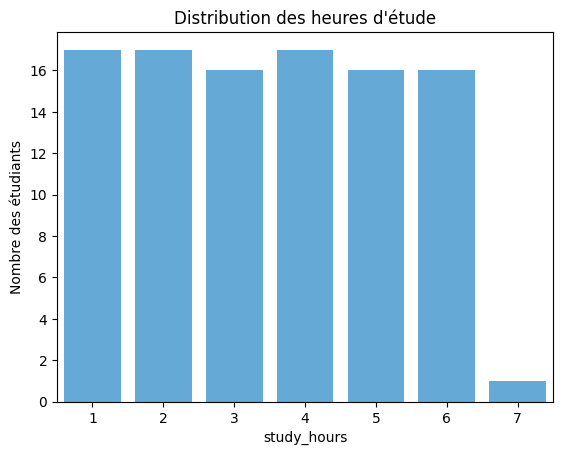

In [27]:
df['study_hours'].value_counts()
sns.countplot(x='study_hours', data=df, color="#52adea")
plt.title("Distribution des heures d'étude")
plt.ylabel("Nombre des étudiants")
plt.show()

* Les heures d'étude varient de 1 à 7h avec une moyenne de 3.5h. La répartition est homogène, indiquant que les différentes durées d’étude sont presque également représentées. Aucun cas extrême ou inhabituel ne se distingue dans ces données.

### Variable 2 : Sleep_hours (Heures de sommeil)

In [28]:
df['sleep_hours'].describe()


count    100.000000
mean       6.080000
std        1.177911
min        4.000000
25%        5.000000
50%        6.000000
75%        7.000000
max        8.000000
Name: sleep_hours, dtype: float64

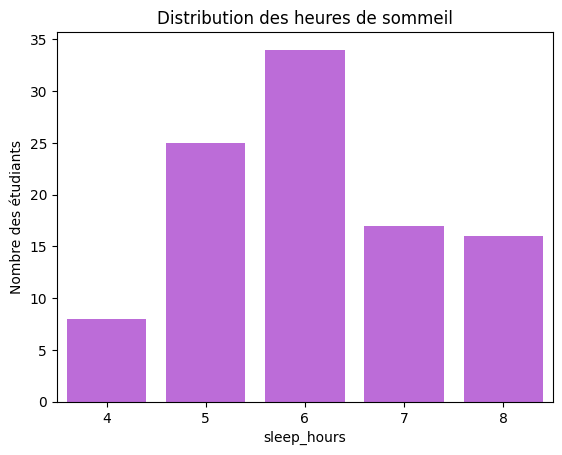

In [29]:
df['sleep_hours'].value_counts()
sns.countplot(x='sleep_hours', data=df, color="#c45aea")
plt.title('Distribution des heures de sommeil')
plt.ylabel("Nombre des étudiants")
plt.show()

* Les heures de sommeil varient de 4 à 8h avec une moyenne de 6.08h. La majorité des étudiants dorment 6h (34 étudiants).

### Variable 3 : social_media_hours (Heures sur les réseaux sociaux)

In [30]:
df['social_media_hours'].describe()

count    100.000000
mean       3.830000
std        2.098845
min        1.000000
25%        2.000000
50%        3.500000
75%        6.000000
max        7.000000
Name: social_media_hours, dtype: float64

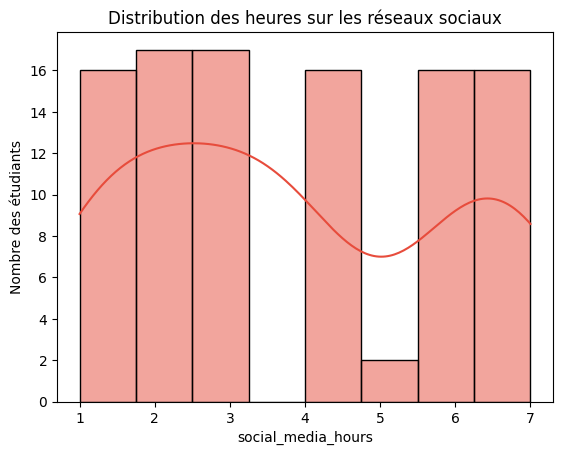

In [31]:
df['social_media_hours'].value_counts()
sns.histplot(df['social_media_hours'], kde=True, color='#e74c3c')
plt.title('Distribution des heures sur les réseaux sociaux')
plt.ylabel('Nombre des étudiants')
plt.show()

Les heures sur les réseaux sociaux varient de 1 à 7h avec une moyenne de 3.83h.

### Variable 4 : stress_level (niveau de stress)

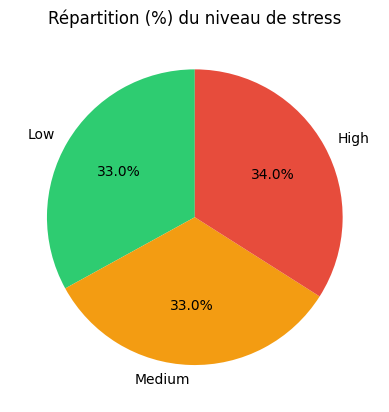

In [32]:
counts = df['stress_level'].value_counts().reindex(['Low', 'Medium', 'High'])
plt.pie(counts.values, labels=['Low', 'Medium', 'High'], colors=["#2ecc71", "#f39c12", "#e74c3c"], autopct='%1.1f%%', startangle=90)
plt.title('Répartition (%) du niveau de stress')
plt.show()

* Le niveau de stress est très bien équilibré dans le dataset : 34% High, 33% Medium, 33% Low. Cette répartition garantit que les analyses comparatives entre les groupes seront fiables.

## Analyse Bivariée Du Jeu De Données

L’analyse bivariée consiste à étudier simultanément deux variables afin d’examiner la relation qui les lie et de mettre en évidence d’éventuelles corrélations.

### 1. study_hours vs exam_score
Est-ce qu'étudier plus améliore les notes ?

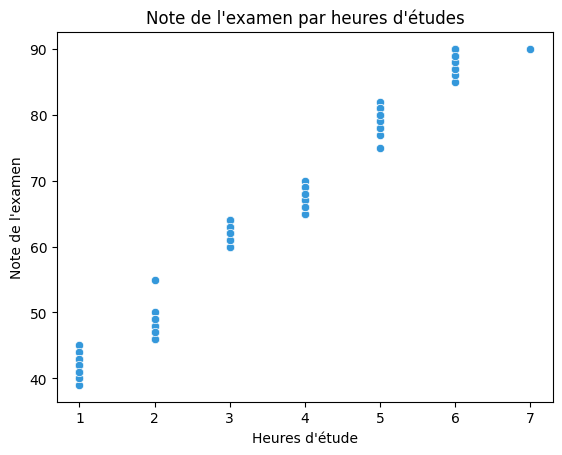

In [33]:
sns.scatterplot(x='study_hours', y='exam_score', data=df, color='#3498db')
plt.title("Note de l'examen par heures d'études")
plt.xlabel("Heures d'étude")
plt.ylabel("Note de l'examen")
plt.show()

### Note moyenne par nombre d'heures d'étude

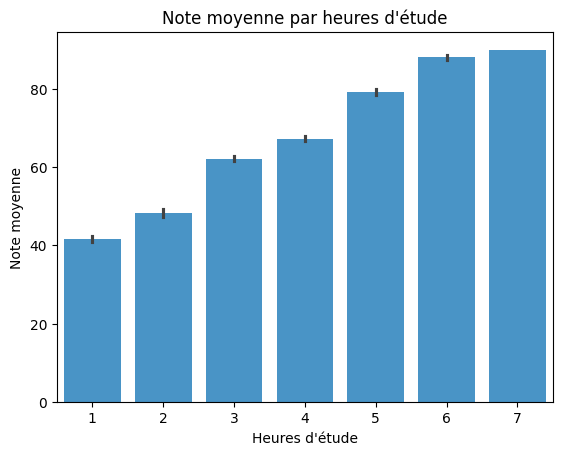

In [34]:
sns.barplot(x='study_hours', y='exam_score', data=df, color='#3498db')
plt.title("Note moyenne par heures d'étude")
plt.xlabel("Heures d'étude")
plt.ylabel("Note moyenne")
plt.show()

* La relation est claire et positive : plus un étudiant travaille, meilleur est son score.
* 1h d'étude → moyenne de 41  
* 7h d'étude → moyenne de 90.

### 2. sleep_hours vs exam_score
Est-ce que dormir plus améliore les résultats ?

### Note moyenne par heures de sommeil

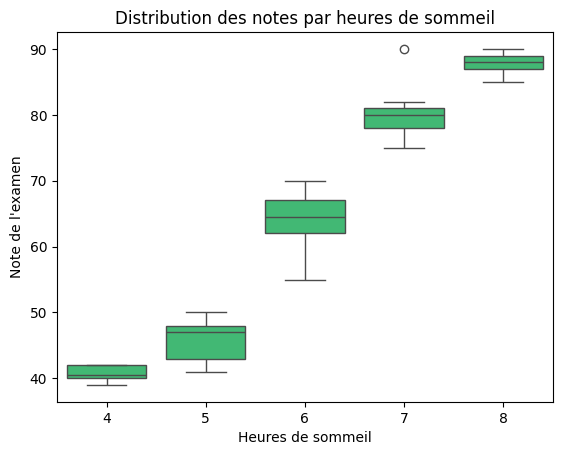

In [35]:
sns.boxplot(x='sleep_hours', y='exam_score', data=df, color='#2ecc71')
plt.title("Distribution des notes par heures de sommeil")
plt.xlabel("Heures de sommeil")
plt.ylabel("Note de l'examen")
plt.show()

* Le sommeil a un impact direct sur les résultats : les étudiants qui dorment 8h obtiennent en moyenne 88 points, contre 40 pour ceux qui dorment 4h.

### 3. social_media_hours vs exam_score
Est-ce que les réseaux sociaux font baisser les notes ?

### Note moyenne par heures sur les réseaux sociaux

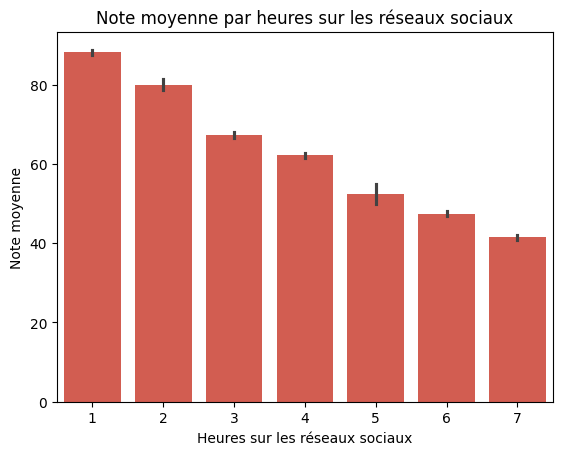

In [36]:
sns.barplot(x='social_media_hours', y='exam_score', data=df, color='#e74c3c')
plt.title("Note moyenne par heures sur les réseaux sociaux")
plt.xlabel("Heures sur les réseaux sociaux")
plt.ylabel("Note moyenne")
plt.show()

La relation est négative : plus les heures sur les réseaux sociaux augmentent, plus le score baisse. 1h → moyenne de 88, 7h → moyenne de 41.

### 4. stress_level vs exam_score
Est-ce que le stress impacte les résultats ?

### Note moyenne par niveau de stress

C:\Users\Lina Ben Slama\AppData\Local\Temp\ipykernel_25788\4278917058.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='stress_level', y='exam_score', data=df, order=['Low', 'Medium', 'High'], palette={'Low': '#2ecc71', 'Medium': '#f39c12', 'High': '#e74c3c'})


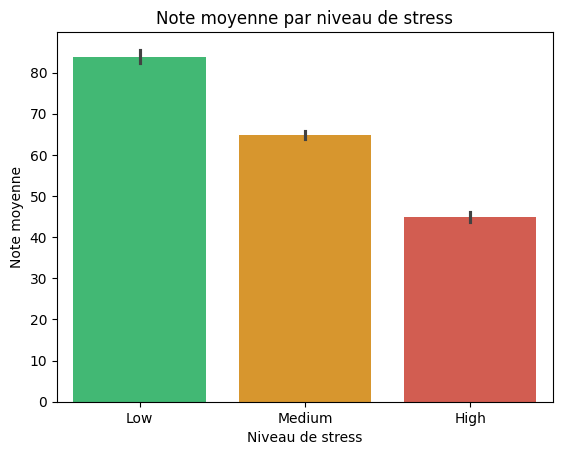

In [37]:
sns.barplot(x='stress_level', y='exam_score', data=df, order=['Low', 'Medium', 'High'], palette={'Low': '#2ecc71', 'Medium': '#f39c12', 'High': '#e74c3c'})
plt.title("Note moyenne par niveau de stress")
plt.xlabel("Niveau de stress")
plt.ylabel("Note moyenne")
plt.show()

* Les étudiants à stress faible obtiennent en moyenne 83.9 points, contre 64.8 pour le stress moyen et 44.9 pour le stress élevé. Le stress est donc fortement lié aux résultats académiques.

### 5. stress_level vs sleep_hours
Est-ce que le manque de sommeil provoque du stress ?

### Moyenne des heures de sommeil par niveau de stress

C:\Users\Lina Ben Slama\AppData\Local\Temp\ipykernel_25788\2349674746.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='stress_level', y='sleep_hours', data=df, order=['Low', 'Medium', 'High'], palette={'Low': '#2ecc71', 'Medium': '#f39c12', 'High': '#e74c3c'})


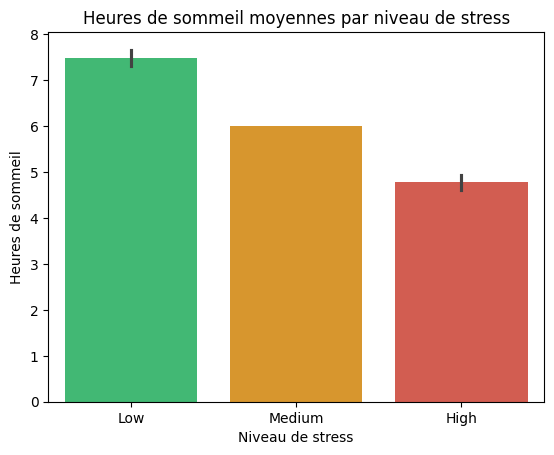

In [38]:
sns.barplot(x='stress_level', y='sleep_hours', data=df, order=['Low', 'Medium', 'High'], palette={'Low': '#2ecc71', 'Medium': '#f39c12', 'High': '#e74c3c'})
plt.title("Heures de sommeil moyennes par niveau de stress")
plt.xlabel("Niveau de stress")
plt.ylabel("Heures de sommeil")
plt.show()

* Les étudiants à stress élevé dorment en moyenne 5h, contre 8h pour ceux à stress faible. Le manque de sommeil est clairement associé à un niveau de stress plus élevé.

### 6. stress_level vs social_media_hours
Est-ce que les réseaux sociaux augmentent le stress ?

### Moyenne des heures sur les réseaux sociaux par niveau de stress

C:\Users\Lina Ben Slama\AppData\Local\Temp\ipykernel_25788\136683236.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='stress_level', y='social_media_hours', data=df, order=['Low', 'Medium', 'High'], palette={'Low': '#2ecc71', 'Medium': '#f39c12', 'High': '#e74c3c'})


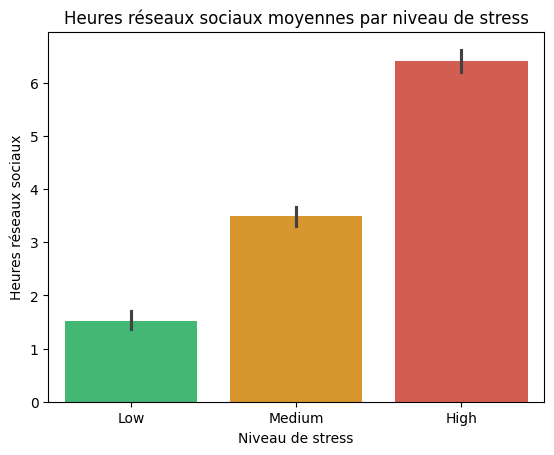

In [39]:
sns.barplot(x='stress_level', y='social_media_hours', data=df, order=['Low', 'Medium', 'High'], palette={'Low': '#2ecc71', 'Medium': '#f39c12', 'High': '#e74c3c'})
plt.title("Heures réseaux sociaux moyennes par niveau de stress")
plt.xlabel("Niveau de stress")
plt.ylabel("Heures réseaux sociaux")
plt.show()

* Les étudiants à stress élevé passent en moyenne 6h sur les réseaux sociaux, contre 1h pour ceux à stress faible. L'usage excessif des réseaux sociaux est fortement associé au stress.

## Analyse des corrélation
Vue globale des relations entre toutes les variables numériques.

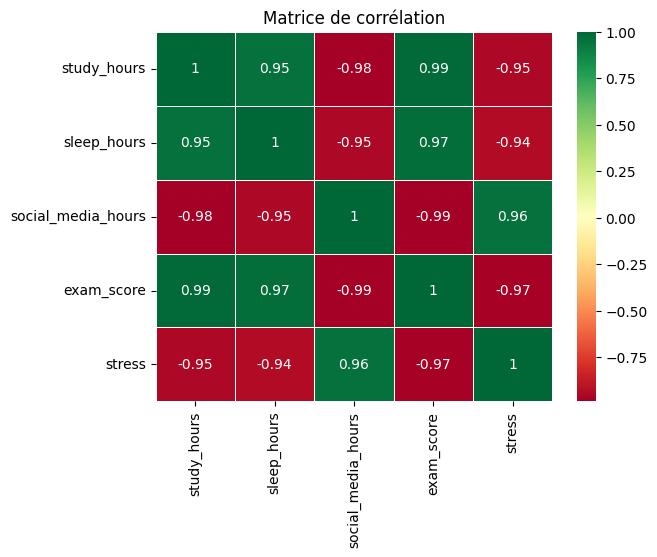

In [40]:
# Encodage du stress pour inclure la variable dans la corrélation
df['stress'] = df['stress_level'].map({'Low': 1, 'Medium': 2, 'High': 3})

cols = ['study_hours', 'sleep_hours', 'social_media_hours', 'exam_score', 'stress']

sns.heatmap(df[cols].corr(), annot=True, cmap='RdYlGn', linewidths=0.5)
plt.title('Matrice de corrélation')
plt.show()

* La matrice confirme toutes nos observations : le score à l'examen est fortement corrélé positivement avec les heures d'étude et de sommeil, et négativement avec les réseaux sociaux et le stress.